In [1]:
# ============================================================
# SETUP INICIAL DEL NOTEBOOK 03_deep_learning.ipynb
# ============================================================
import pandas as pd
import numpy as np
import json
import time
from pathlib import Path
import random

# Rutas
DATA_DIR    = Path(r"E:\USUARIO\Desktop\Dataset 5")
MODELS_DIR  = DATA_DIR / "models"
RESULTS_DIR = DATA_DIR / "results"
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Semilla global - FIJAR ANTES de importar TF
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Importar TensorFlow (tarda unos segundos)
print("Importando TensorFlow...")
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # silenciar warnings
import tensorflow as tf
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Cargar datos
df_clean = pd.read_parquet(DATA_DIR / "Dataset_clean.parquet")
with open(DATA_DIR / "features_finales.json") as f:
    features_28 = json.load(f)

with np.load(DATA_DIR / "splits.npz") as npz:
    X_train = npz['X_train']
    X_test  = npz['X_test']
    y_train = npz['y_train']
    y_test  = npz['y_test']

print(f"\nDatos cargados:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

# Función de resumen (igual que en el notebook 02)
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)

def resumen_modelo(nombre, y_true, y_pred, y_scores, tiempo_train):
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_scores) if y_scores is not None else np.nan
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n=== {nombre} ===")
    print(f"Tiempo entrenamiento: {tiempo_train:.2f} s")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"Matriz de confusión:")
    print(f"          pred=0    pred=1")
    print(f"real=0    {tn:6d}    {fp:6d}")
    print(f"real=1    {fn:6d}    {tp:6d}")
    return {
        'modelo': nombre, 'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'F1': round(f1, 4), 'AUC_ROC': round(auc, 4),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'tiempo_s': round(tiempo_train, 2)
    }

metricas_dl = []

Importando TensorFlow...
TensorFlow: 2.21.0
GPU disponible: False

Datos cargados:
  X_train: (30788, 28)
  X_test:  (13196, 28)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Fijar semillas antes de construir el modelo
tf.keras.utils.set_random_seed(SEED)

# --- ARQUITECTURA MLP ---
mlp = Sequential([
    Input(shape=(28,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp.summary()
print()

# --- ENTRENAMIENTO CON EARLY STOPPING ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Peso de clases (68,30% normal, 31,70% ataque → 0.732 / 1.577)
class_weight = {0: 0.732, 1: 1.577}

t0 = time.time()
history = mlp.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)
tiempo_mlp = time.time() - t0

# Predicciones
y_scores_mlp = mlp.predict(X_test, verbose=0).flatten()
y_pred_mlp   = (y_scores_mlp > 0.5).astype(int)

# Métricas
m_mlp = resumen_modelo("MLP", y_test, y_pred_mlp, y_scores_mlp, tiempo_mlp)
metricas_dl.append(m_mlp)

# Guardar
mlp.save(MODELS_DIR / "mlp.keras")
np.save(RESULTS_DIR / "preds_mlp.npy", y_pred_mlp)
np.save(RESULTS_DIR / "scores_mlp.npy", y_scores_mlp)
print(f"\nMLP entrenado en {tiempo_mlp:.2f} s, épocas ejecutadas: {len(history.history['loss'])}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │           1,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7170 - loss: 0.5672 - val_accuracy: 0.8396 - val_loss: 0.4688
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.5094 - val_accuracy: 0.8470 - val_loss: 0.4483
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8287 - loss: 0.4901 - val_accuracy: 0.8542 - val_loss: 0.4277
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8368 - loss: 0.4745 - val_accuracy: 0.8551 - val_loss: 0.4287
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8437 - loss: 0.4639 - val_accuracy: 0.8548 - val_loss: 0.4203
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8463 - loss: 0.4562 - val_accuracy: 0.8558 - val_loss: 0.4135
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8502 - loss: 0.4510 - val_accuracy: 0.8551 - val_loss: 0.4130
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8517 - loss: 0.4502 - val_accuracy: 0.8548 - 

In [4]:
# Fijar semillas
tf.keras.utils.set_random_seed(SEED)

# Para el AE solo entrenamos con flujos normales del train
X_train_normal = X_train[y_train == 0]
print(f"Flujos normales para entrenar el AE: {len(X_train_normal):,}")
print()

# --- ARQUITECTURA 28 → 64 → 32 → 16 → 32 → 64 → 28 ---
autoencoder = Sequential([
    Input(shape=(28,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),       # cuello de botella
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(28, activation='linear')
])

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()
print()

# --- ENTRENAMIENTO ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

t0 = time.time()
history_ae = autoencoder.fit(
    X_train_normal, X_train_normal,
    validation_split=0.20,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
tiempo_ae = time.time() - t0

# --- ERROR DE RECONSTRUCCIÓN EN TRAIN NORMAL ---
X_train_pred = autoencoder.predict(X_train_normal, verbose=0)
errors_train = np.mean((X_train_normal - X_train_pred)**2, axis=1)
umbral_ae = np.percentile(errors_train, 95)
print(f"\nUmbral del AE (percentil 95 del error en train normal): {umbral_ae:.6f}")

# --- ERROR DE RECONSTRUCCIÓN EN TEST ---
X_test_pred = autoencoder.predict(X_test, verbose=0)
y_scores_ae = np.mean((X_test - X_test_pred)**2, axis=1)
y_pred_ae   = (y_scores_ae > umbral_ae).astype(int)

# Métricas
m_ae = resumen_modelo("Autoencoder denso", y_test, y_pred_ae, y_scores_ae, tiempo_ae)
metricas_dl.append(m_ae)

# Guardar
autoencoder.save(MODELS_DIR / "autoencoder.keras")
np.save(RESULTS_DIR / "preds_ae.npy", y_pred_ae)
np.save(RESULTS_DIR / "scores_ae.npy", y_scores_ae)
print(f"\nAutoencoder entrenado en {tiempo_ae:.2f} s, épocas ejecutadas: {len(history_ae.history['loss'])}")

Flujos normales para entrenar el AE: 21,029



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 64)                  │           1,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 28)                  │           1,820 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,940 (34.92 KB)

 Trainable params: 8,940 (34.92 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1721 - val_loss: 0.0569
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0381 - val_loss: 0.0314
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0195 - val_loss: 0.0161
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0100 - val_loss: 0.0098
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0064 - val_loss: 0.0071
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0049 - val_loss: 0.0056
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - val_loss: 0.0043
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - val_loss: 0.0039
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024 - val_loss: 0.0031
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - val_loss: 0.0034
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

In [5]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, UpSampling1D, Flatten, Reshape

# Fijar semillas
tf.keras.utils.set_random_seed(SEED)

# El CNN 1D necesita entrada 3D: (samples, timesteps, channels)
X_train_normal_3d = X_train_normal.reshape(-1, 28, 1)
X_train_3d        = X_train.reshape(-1, 28, 1)
X_test_3d         = X_test.reshape(-1, 28, 1)

# --- ARQUITECTURA CNN 1D AE ---
cnn_ae = Sequential([
    Input(shape=(28, 1)),
    # Encoder
    Conv1D(32, 3, activation='relu', padding='same'),
    MaxPooling1D(2, padding='same'),              # 28 → 14
    Conv1D(16, 3, activation='relu', padding='same'),
    MaxPooling1D(2, padding='same'),              # 14 → 7
    # Decoder
    Conv1D(16, 3, activation='relu', padding='same'),
    UpSampling1D(2),                               # 7 → 14
    Conv1D(32, 3, activation='relu', padding='same'),
    UpSampling1D(2),                               # 14 → 28
    Conv1D(1,  3, activation='linear', padding='same')
])

cnn_ae.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

cnn_ae.summary()
print()

# --- ENTRENAMIENTO ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

t0 = time.time()
history_cnn = cnn_ae.fit(
    X_train_normal_3d, X_train_normal_3d,
    validation_split=0.20,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
tiempo_cnn = time.time() - t0

# --- UMBRAL ---
X_train_pred_cnn = cnn_ae.predict(X_train_normal_3d, verbose=0)
errors_train_cnn = np.mean((X_train_normal_3d - X_train_pred_cnn)**2, axis=(1, 2))
umbral_cnn = np.percentile(errors_train_cnn, 95)
print(f"\nUmbral del CNN 1D AE (percentil 95): {umbral_cnn:.6f}")

# --- EVALUACIÓN ---
X_test_pred_cnn = cnn_ae.predict(X_test_3d, verbose=0)
y_scores_cnn = np.mean((X_test_3d - X_test_pred_cnn)**2, axis=(1, 2))
y_pred_cnn   = (y_scores_cnn > umbral_cnn).astype(int)

# Métricas
m_cnn = resumen_modelo("CNN 1D Autoencoder", y_test, y_pred_cnn, y_scores_cnn, tiempo_cnn)
metricas_dl.append(m_cnn)

# Guardar
cnn_ae.save(MODELS_DIR / "cnn_ae.keras")
np.save(RESULTS_DIR / "preds_cnn.npy", y_pred_cnn)
np.save(RESULTS_DIR / "scores_cnn.npy", y_scores_cnn)
print(f"\nCNN 1D AE entrenado en {tiempo_cnn:.2f} s, épocas ejecutadas: {len(history_cnn.history['loss'])}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 28, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 14, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 14, 16)              │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 7, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 7, 16)               │             784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling1d (UpSampling1D)         │ (None, 14, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 14, 32)              │           1,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling1d_1 (UpSampling1D)       │ (None, 28, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 28, 1)               │              97 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,129 (16.13 KB)

 Trainable params: 4,129 (16.13 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2403 - val_loss: 0.1722
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1006 - val_loss: 0.0590
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0346 - val_loss: 0.0263
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0193 - val_loss: 0.0192
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0149 - val_loss: 0.0156
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0123 - val_loss: 0.0131
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0104 - val_loss: 0.0112
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - val_loss: 0.0096
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0078 - val_loss: 0.0084
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0070 - val_loss: 0.0075
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0063 - val_loss: 0.0068
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0

In [6]:
# Cargar las métricas de ML del notebook anterior
df_ml = pd.read_csv(RESULTS_DIR / "metricas_modelos_ml.csv")

# Añadir las métricas de DL
df_dl = pd.DataFrame(metricas_dl)

# Tabla consolidada de los 8 modelos
df_todos = pd.concat([df_ml, df_dl], ignore_index=True)
df_todos = df_todos.sort_values('F1', ascending=False).reset_index(drop=True)
df_todos.to_csv(RESULTS_DIR / "metricas_todos.csv", index=False)

print("=== COMPARATIVA GLOBAL DE LOS 8 MODELOS ===")
print(df_todos.to_string(index=False))

=== COMPARATIVA GLOBAL DE LOS 8 MODELOS ===
            modelo  Precision  Recall     F1  AUC_ROC   TP  FP   FN   TN  tiempo_s
           XGBoost     0.8207  0.7169 0.7653   0.8803 2999 655 1184 8358      0.65
     Random Forest     0.8731  0.6758 0.7619   0.8771 2827 411 1356 8602      3.84
               MLP     0.9198  0.6029 0.7284   0.8274 2522 220 1661 8793     14.65
               MLP     0.9198  0.6029 0.7284   0.8274 2522 220 1661 8793     11.28
 Autoencoder denso     0.8411  0.5960 0.6976   0.7889 2493 471 1690 8542     11.33
               LOF     0.8395  0.5965 0.6974   0.8060 2495 477 1688 8536      2.17
CNN 1D Autoencoder     0.8337  0.5728 0.6790   0.7795 2396 478 1787 8535     55.38
    Baseline (k=2)     0.7500  0.5114 0.6081   0.7137 2139 713 2044 8300      0.13
  Isolation Forest     0.7882  0.3727 0.5061   0.7431 1559 419 2624 8594      0.78


In [7]:
# ============================================================
# DETECTABILIDAD POR TIPO DE ATAQUE
# ============================================================

# Cargar etiquetas multiclase del test
with np.load(DATA_DIR / "splits_multi.npz", allow_pickle=True) as npz:
    y_test_multi = npz['y_test_multi']

# Cargar todas las predicciones guardadas
modelos_preds = {
    'Baseline (k=2)':    None,  # lo calculamos aparte
    'Random Forest':     np.load(RESULTS_DIR / "preds_rf.npy"),
    'XGBoost':           np.load(RESULTS_DIR / "preds_xgb.npy"),
    'Isolation Forest':  np.load(RESULTS_DIR / "preds_iforest.npy"),
    'LOF':               np.load(RESULTS_DIR / "preds_lof.npy"),
    'MLP':               np.load(RESULTS_DIR / "preds_mlp.npy"),
    'Autoencoder':       np.load(RESULTS_DIR / "preds_ae.npy"),
    'CNN 1D AE':         np.load(RESULTS_DIR / "preds_cnn.npy"),
}

# Regenerar predicción del baseline con k=2 (no la guardamos binaria)
z_scores_test = np.load(DATA_DIR / "baseline_scores.npy")
modelos_preds['Baseline (k=2)'] = (z_scores_test > 2.0).astype(int)

# Calcular tasa de detección para cada tipo de ataque
tipos_ataque = ['port-scan', 'ip-scan', 'mitm', 'replay', 'ddos']
orden_modelos = ['Baseline (k=2)', 'Random Forest', 'XGBoost', 'Isolation Forest',
                 'LOF', 'MLP', 'Autoencoder', 'CNN 1D AE']

detectabilidad = pd.DataFrame(index=tipos_ataque, columns=orden_modelos, dtype=float)

for modelo in orden_modelos:
    preds = modelos_preds[modelo]
    for tipo in tipos_ataque:
        mask = (y_test_multi == tipo)
        n_total = mask.sum()
        n_detectados = ((preds == 1) & mask).sum()
        tasa = 100 * n_detectados / n_total if n_total > 0 else 0
        detectabilidad.loc[tipo, modelo] = round(tasa, 1)

# También sobre el tráfico normal: tasa de falsos positivos
for modelo in orden_modelos:
    preds = modelos_preds[modelo]
    mask_normal = (y_test_multi == 'Normal')
    n_total = mask_normal.sum()
    n_falsos_pos = ((preds == 1) & mask_normal).sum()
    fpr = 100 * n_falsos_pos / n_total
    detectabilidad.loc['Normal (FPR)', modelo] = round(fpr, 1)

print("=== TASA DE DETECCIÓN POR TIPO DE ATAQUE (%) ===")
print("Nota: última fila = False Positive Rate sobre tráfico normal")
print()
print(detectabilidad.to_string())

# Recuento de flujos en test por tipo
print("\n=== NÚMERO DE FLUJOS EN TEST POR TIPO ===")
print(pd.Series(y_test_multi).value_counts())

# Guardar para el heatmap
detectabilidad.to_csv(RESULTS_DIR / "detectabilidad_por_tipo.csv")
print(f"\nGuardado en: {RESULTS_DIR / 'detectabilidad_por_tipo.csv'}")

=== TASA DE DETECCIÓN POR TIPO DE ATAQUE (%) ===
Nota: última fila = False Positive Rate sobre tráfico normal

              Baseline (k=2)  Random Forest  XGBoost  Isolation Forest   LOF   MLP  Autoencoder  CNN 1D AE
port-scan               59.0           71.0     76.6              55.1  56.1  58.3         55.3       55.5
ip-scan                  8.7            9.3     19.3               3.3   2.0   6.7          2.7        4.0
mitm                    84.8           88.4     89.3              85.3  84.4  86.8         86.8       85.9
replay                  21.8           55.1     57.0               4.8  52.1  49.7         51.0       44.4
ddos                    57.3           71.1     77.4              30.2  60.9  61.7         60.7       59.3
Normal (FPR)             7.9            4.6      7.3               4.6   5.3   2.4          5.2        5.3

=== NÚMERO DE FLUJOS EN TEST POR TIPO ===
Normal       9013
ddos         1286
replay       1148
port-scan     842
mitm          757
ip-scan

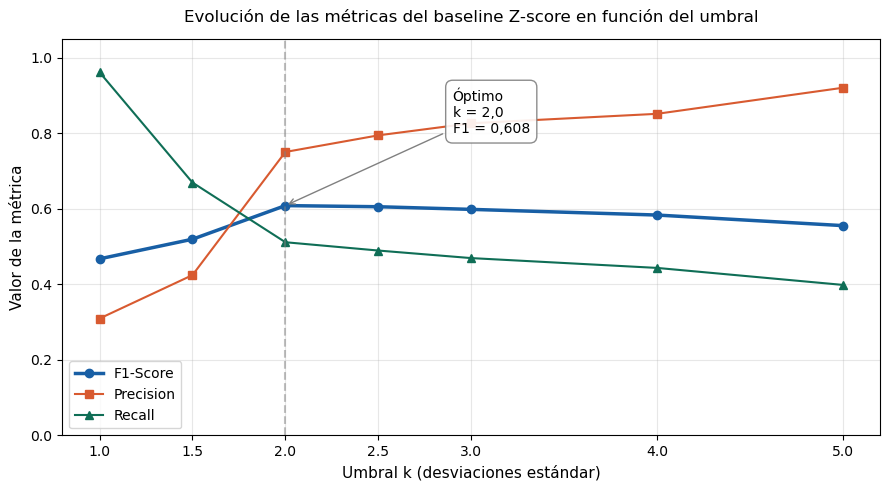

Figura guardada en: E:\USUARIO\Desktop\Dataset 5\figures\fig_6_1_baseline_umbrales.png


In [8]:
import matplotlib.pyplot as plt

# Datos del baseline
ks  = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
f1  = [0.467, 0.519, 0.608, 0.605, 0.598, 0.583, 0.555]
pre = [0.309, 0.424, 0.750, 0.794, 0.826, 0.851, 0.920]
rec = [0.961, 0.669, 0.511, 0.489, 0.469, 0.443, 0.398]

# Paleta coherente con el resto del TFG
color_f1   = '#185FA5'   # azul (destacar)
color_pre  = '#D85A30'   # coral
color_rec  = '#0F6E56'   # verde agua

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(ks, f1,  marker='o', linewidth=2.5, color=color_f1,  label='F1-Score')
ax.plot(ks, pre, marker='s', linewidth=1.5, color=color_pre, label='Precision')
ax.plot(ks, rec, marker='^', linewidth=1.5, color=color_rec, label='Recall')

# Marcar el punto óptimo (k = 2,0, F1 = 0,608)
ax.axvline(x=2.0, color='gray', linestyle='--', alpha=0.5)
ax.annotate('Óptimo\nk = 2,0\nF1 = 0,608',
            xy=(2.0, 0.608), xytext=(2.9, 0.80),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', alpha=0.9))

ax.set_xlabel('Umbral k (desviaciones estándar)', fontsize=11)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Evolución de las métricas del baseline Z-score en función del umbral', fontsize=12, pad=12)
ax.legend(loc='lower left', frameon=True)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.set_xticks(ks)
plt.tight_layout()

FIGURES_DIR = DATA_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
out_png = FIGURES_DIR / "fig_6_1_baseline_umbrales.png"
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figura guardada en: {out_png}")

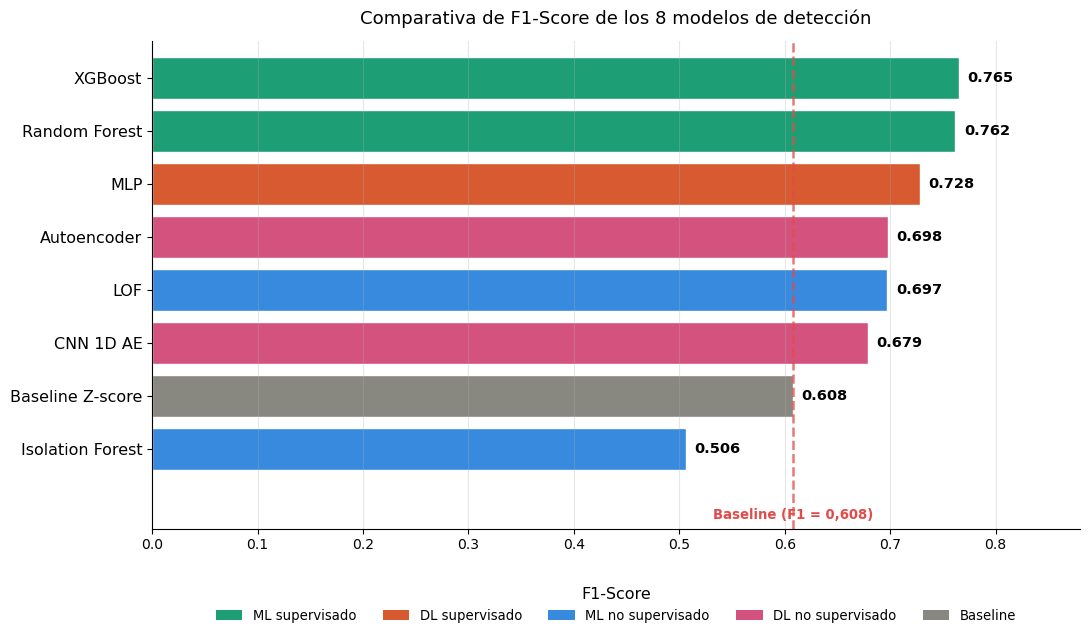

Guardada en: E:\USUARIO\Desktop\Dataset 5\figures\fig_6_2_comparativa_f1.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

modelos = ['XGBoost', 'Random Forest', 'MLP', 'Autoencoder', 'LOF',
           'CNN 1D AE', 'Baseline Z-score', 'Isolation Forest']
f1_values = [0.7653, 0.7619, 0.7284, 0.6976, 0.6974, 0.6790, 0.6081, 0.5061]

colores_familia = {
    'XGBoost':          '#1D9E75',
    'Random Forest':    '#1D9E75',
    'MLP':              '#D85A30',
    'Autoencoder':      '#D4537E',
    'LOF':              '#378ADD',
    'CNN 1D AE':        '#D4537E',
    'Baseline Z-score': '#888780',
    'Isolation Forest': '#378ADD',
}
colors = [colores_familia[m] for m in modelos]

fig, ax = plt.subplots(figsize=(11, 6.5))
y_pos = np.arange(len(modelos))
bars = ax.barh(y_pos, f1_values, color=colors, edgecolor='white', linewidth=1)

# Etiquetas de valor a la derecha de cada barra
for bar, v in zip(bars, f1_values):
    ax.text(v + 0.008, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left',
            fontsize=10.5, fontweight='bold')

# Línea del baseline con etiqueta ABAJO (cerca del eje X, sin tapar barras)
ax.axvline(x=0.6081, color='#E24B4A', linestyle='--', linewidth=1.8, alpha=0.75)
ax.text(0.6081, 8.1, 'Baseline (F1 = 0,608)',
        ha='center', va='top', fontsize=9.5, color='#E24B4A',
        fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(modelos, fontsize=11.5)
ax.invert_yaxis()
ax.set_xlabel('F1-Score', fontsize=11.5, labelpad=25)  # espacio extra para la etiqueta del baseline
ax.set_title('Comparativa de F1-Score de los 8 modelos de detección',
             fontsize=13, pad=12)
ax.set_xlim(0, 0.88)
ax.set_ylim(8.5, -0.7)  # extender hacia abajo para el texto del baseline
ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Leyenda de familias debajo
legend_familias = [
    Patch(facecolor='#1D9E75', label='ML supervisado'),
    Patch(facecolor='#D85A30', label='DL supervisado'),
    Patch(facecolor='#378ADD', label='ML no supervisado'),
    Patch(facecolor='#D4537E', label='DL no supervisado'),
    Patch(facecolor='#888780', label='Baseline'),
]
ax.legend(handles=legend_familias, loc='upper center',
          bbox_to_anchor=(0.5, -0.14),
          ncol=5, fontsize=9.5, frameon=False)

plt.tight_layout()
out_png = FIGURES_DIR / "fig_6_2_comparativa_f1.png"
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print(f"Guardada en: {out_png}")

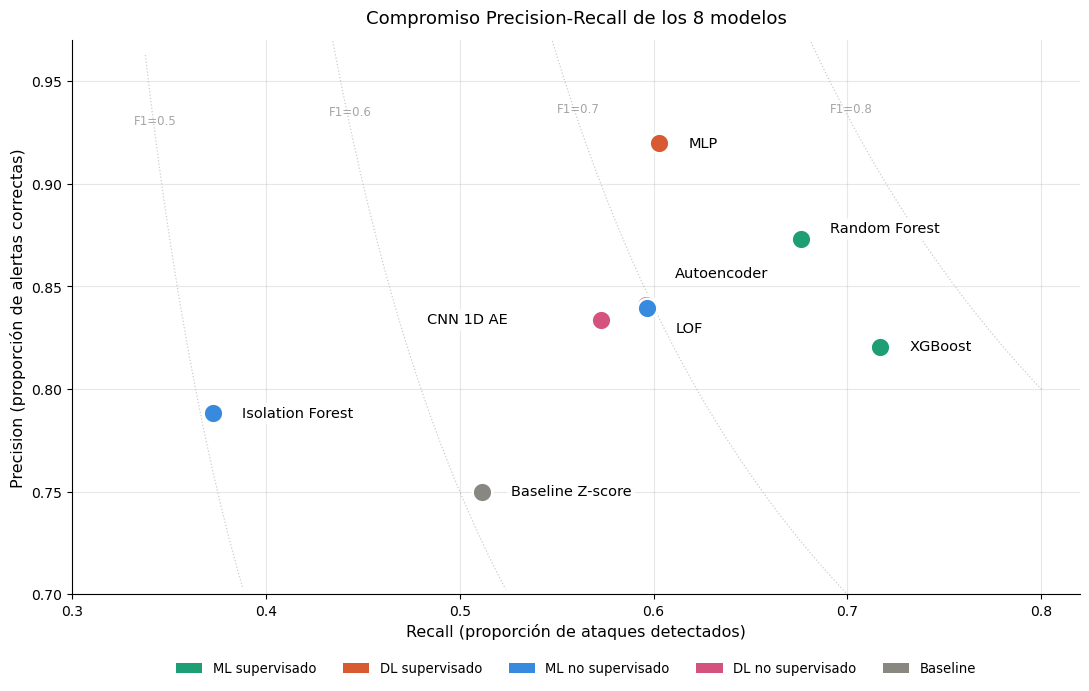

Guardada en: E:\USUARIO\Desktop\Dataset 5\figures\fig_6_3_precision_recall.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

puntos = {
    'XGBoost':          (0.7169, 0.8207),
    'Random Forest':    (0.6758, 0.8731),
    'MLP':              (0.6029, 0.9198),
    'Autoencoder':      (0.5960, 0.8411),
    'LOF':              (0.5965, 0.8395),
    'CNN 1D AE':        (0.5728, 0.8337),
    'Baseline Z-score': (0.5114, 0.7500),
    'Isolation Forest': (0.3727, 0.7882),
}

offsets = {
    'XGBoost':          (0.015, 0.000),
    'Random Forest':    (0.015, 0.005),
    'MLP':              (0.015, 0.000),
    'Autoencoder':      (0.015, 0.015),
    'LOF':              (0.015, -0.010),
    'CNN 1D AE':        (-0.090, 0.000),
    'Baseline Z-score': (0.015, 0.000),
    'Isolation Forest': (0.015, 0.000),
}

colores = {
    'XGBoost':          '#1D9E75',
    'Random Forest':    '#1D9E75',
    'MLP':              '#D85A30',
    'Autoencoder':      '#D4537E',
    'LOF':              '#378ADD',
    'CNN 1D AE':        '#D4537E',
    'Baseline Z-score': '#888780',
    'Isolation Forest': '#378ADD',
}

fig, ax = plt.subplots(figsize=(11, 7))

for nombre, (rec, prec) in puntos.items():
    ax.scatter(rec, prec, s=200, color=colores[nombre],
               edgecolor='white', linewidth=1.8, zorder=4)
    ox, oy = offsets[nombre]
    ax.annotate(nombre, xy=(rec, prec), xytext=(rec+ox, prec+oy),
                fontsize=10.5, ha='left', va='center', zorder=5,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='none', alpha=0.9))

# Líneas de F1 constante (sin warning: evitamos división por cero con np.where)
recalls_line = np.linspace(0.3, 0.8, 200)
for f1_ref in [0.5, 0.6, 0.7, 0.8]:
    denom = 2*recalls_line - f1_ref
    # Sólo calculamos donde el denominador es positivo y lo suficientemente grande
    safe = denom > 0.05
    rec_safe = recalls_line[safe]
    prec_line = f1_ref * rec_safe / (2*rec_safe - f1_ref)
    valid = (prec_line >= 0.70) & (prec_line <= 0.98)
    ax.plot(rec_safe[valid], prec_line[valid],
            linestyle=':', color='gray', alpha=0.4, linewidth=0.9, zorder=1)
    # Etiqueta del F1
    if valid.any():
        idx = np.argmin(np.abs(prec_line - 0.93))
        if valid[idx]:
            ax.text(rec_safe[idx], prec_line[idx]+0.005, f'F1={f1_ref:.1f}',
                    fontsize=8.5, color='gray', alpha=0.7, ha='center', zorder=2)

ax.set_xlabel('Recall (proporción de ataques detectados)', fontsize=11.5)
ax.set_ylabel('Precision (proporción de alertas correctas)', fontsize=11.5)
ax.set_title('Compromiso Precision-Recall de los 8 modelos',
             fontsize=13, pad=12)
ax.set_xlim(0.30, 0.82)
ax.set_ylim(0.70, 0.97)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_familias = [
    Patch(facecolor='#1D9E75', label='ML supervisado'),
    Patch(facecolor='#D85A30', label='DL supervisado'),
    Patch(facecolor='#378ADD', label='ML no supervisado'),
    Patch(facecolor='#D4537E', label='DL no supervisado'),
    Patch(facecolor='#888780', label='Baseline'),
]
ax.legend(handles=legend_familias, loc='upper center',
          bbox_to_anchor=(0.5, -0.10),
          ncol=5, fontsize=9.5, frameon=False)

plt.tight_layout()
out_png = FIGURES_DIR / "fig_6_3_precision_recall.png"
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print(f"Guardada en: {out_png}")

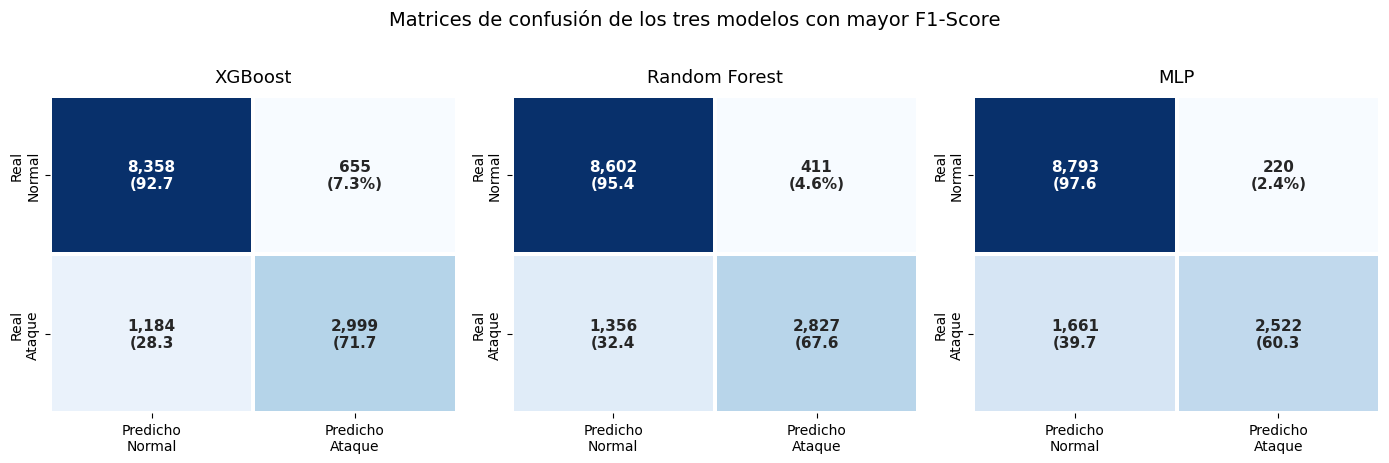

Guardada en: E:\USUARIO\Desktop\Dataset 5\figures\fig_6_4_matrices_confusion.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Matrices de confusión de los 3 mejores modelos (TN, FP, FN, TP)
matrices = {
    'XGBoost':       np.array([[8358,  655], [1184, 2999]]),
    'Random Forest': np.array([[8602,  411], [1356, 2827]]),
    'MLP':           np.array([[8793,  220], [1661, 2522]]),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (nombre, cm) in zip(axes, matrices.items()):
    # Calcular porcentajes sobre cada fila (clase real)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    # Etiquetas con valor absoluto + porcentaje
    annots = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annots[i, j] = f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)'

    sns.heatmap(cm, annot=annots, fmt='', cmap='Blues',
                cbar=False, ax=ax,
                xticklabels=['Predicho\nNormal', 'Predicho\nAtaque'],
                yticklabels=['Real\nNormal', 'Real\nAtaque'],
                linewidths=1.5, linecolor='white',
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    ax.set_title(nombre, fontsize=13, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=10)

plt.suptitle('Matrices de confusión de los tres modelos con mayor F1-Score',
             fontsize=14, y=1.02)
plt.tight_layout()

out_png = FIGURES_DIR / "fig_6_4_matrices_confusion.png"
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print(f"Guardada en: {out_png}")

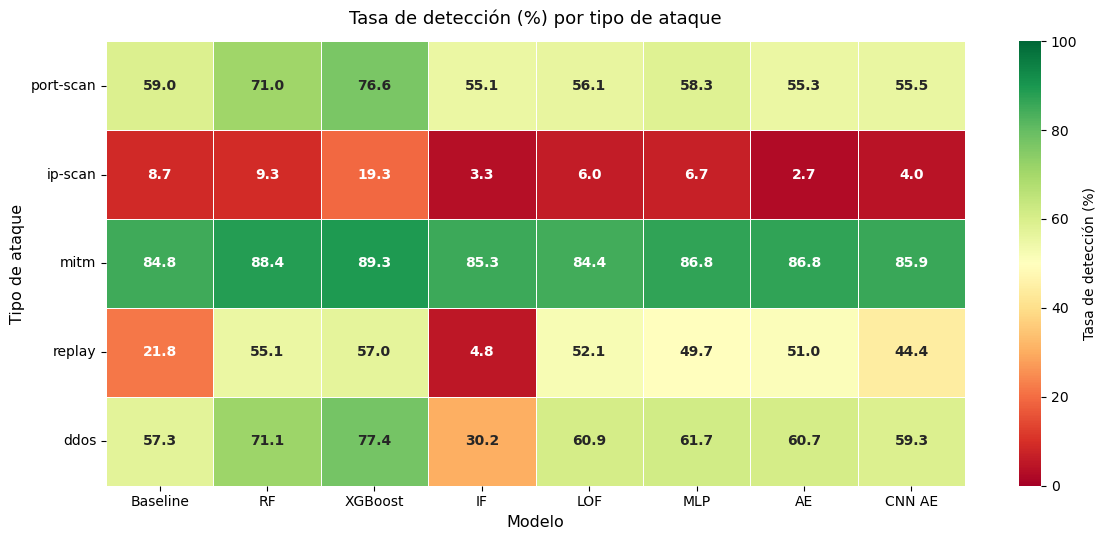

Guardada en: E:\USUARIO\Desktop\Dataset 5\figures\fig_6_5_heatmap_detectabilidad.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Datos verificados
datos = {
    'Baseline':         [59.0, 8.7, 84.8, 21.8, 57.3],
    'RF':               [71.0, 9.3, 88.4, 55.1, 71.1],
    'XGBoost':          [76.6, 19.3, 89.3, 57.0, 77.4],
    'IF':               [55.1, 3.3, 85.3, 4.8, 30.2],
    'LOF':              [56.1, 6.0, 84.4, 52.1, 60.9],
    'MLP':              [58.3, 6.7, 86.8, 49.7, 61.7],
    'AE':               [55.3, 2.7, 86.8, 51.0, 60.7],
    'CNN AE':           [55.5, 4.0, 85.9, 44.4, 59.3],
}
tipos = ['port-scan', 'ip-scan', 'mitm', 'replay', 'ddos']

# DataFrame con modelos en columnas, tipos en filas
df_heat = pd.DataFrame(datos, index=tipos)

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(df_heat, annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Tasa de detección (%)'},
            linewidths=0.5, linecolor='white',
            annot_kws={'fontsize': 10, 'fontweight': 'bold'},
            ax=ax)

ax.set_title('Tasa de detección (%) por tipo de ataque', fontsize=13, pad=12)
ax.set_xlabel('Modelo', fontsize=11.5)
ax.set_ylabel('Tipo de ataque', fontsize=11.5)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
out_png = FIGURES_DIR / "fig_6_5_heatmap_detectabilidad.png"
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print(f"Guardada en: {out_png}")

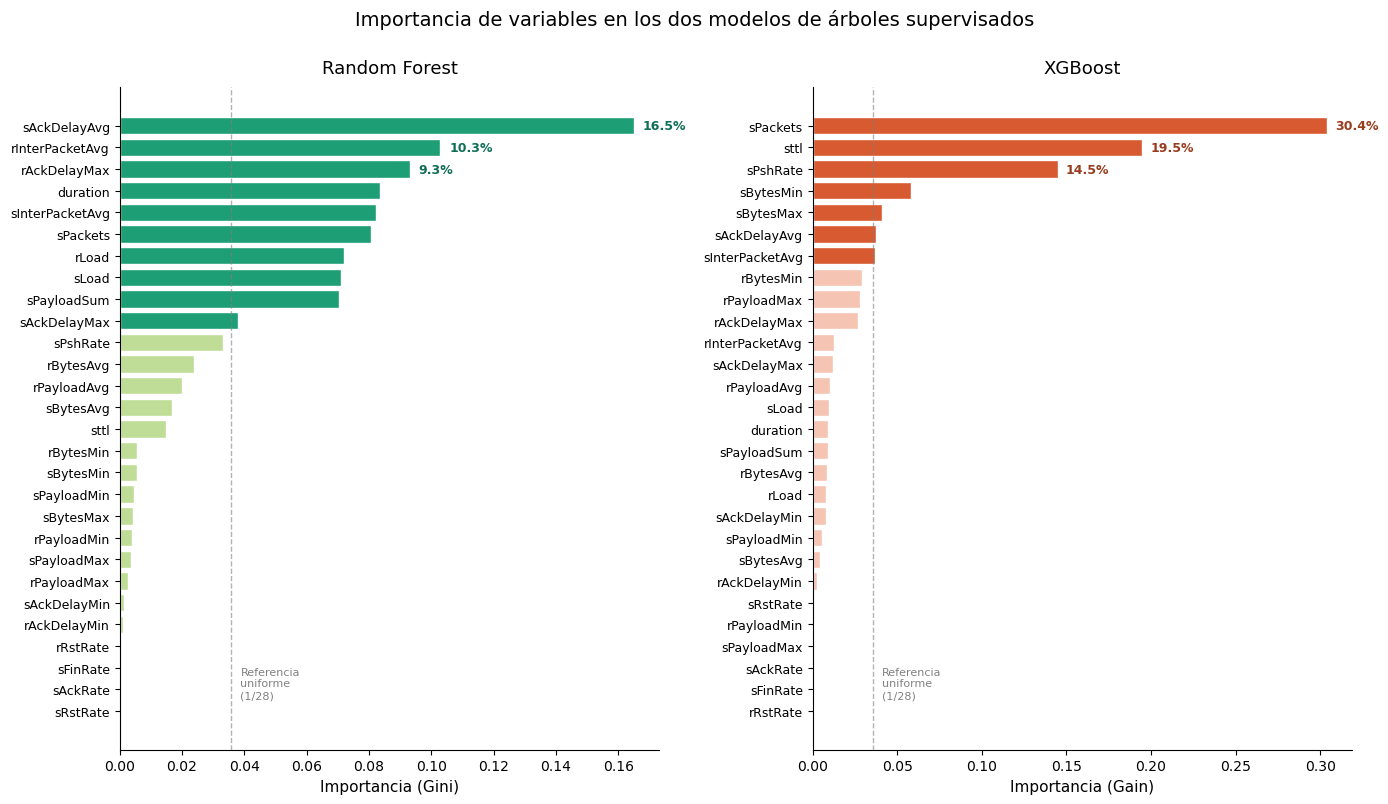

=== TOP 10 RF ===
        feature  importancia
   sAckDelayAvg     0.164891
rInterPacketAvg     0.102915
   rAckDelayMax     0.092980
       duration     0.083539
sInterPacketAvg     0.082099
       sPackets     0.080591
          rLoad     0.072064
          sLoad     0.070853
    sPayloadSum     0.070463
   sAckDelayMax     0.038068

Suma top 10 RF: 85.8%

=== TOP 10 XGBoost ===
        feature  importancia
       sPackets     0.303729
           sttl     0.194568
       sPshRate     0.144723
      sBytesMin     0.058188
      sBytesMax     0.041220
   sAckDelayAvg     0.037232
sInterPacketAvg     0.037150
      rBytesMin     0.029386
    rPayloadMax     0.028059
   rAckDelayMax     0.026552

Suma top 10 XGBoost: 90.1%

sAckDelayAvg en XGBoost: posición 6, importancia 3.72%


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Cargar las importancias guardadas
imp_rf = pd.read_csv(RESULTS_DIR / "importancia_rf.csv")
imp_xgb = pd.read_csv(RESULTS_DIR / "importancia_xgb.csv")

# Ordenar (ya vienen ordenadas, pero por si acaso)
imp_rf = imp_rf.sort_values('importancia', ascending=True)
imp_xgb = imp_xgb.sort_values('importancia', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# --- RANDOM FOREST ---
ax = axes[0]
colors_rf = ['#1D9E75' if v >= 1/28 else '#C0DD97' for v in imp_rf['importancia']]
ax.barh(imp_rf['feature'], imp_rf['importancia'], color=colors_rf, edgecolor='white')
ax.axvline(x=1/28, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(1/28 + 0.003, 0.5, f'Referencia\nuniforme\n(1/28)',
        fontsize=8, color='gray', va='bottom')
ax.set_title('Random Forest', fontsize=13, pad=10)
ax.set_xlabel('Importancia (Gini)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Destacar el top 3
for i, (feat, val) in enumerate(zip(imp_rf['feature'].values, imp_rf['importancia'].values)):
    if val > 0.09:  # Top 3
        ax.text(val + 0.003, i, f'{val*100:.1f}%',
                fontsize=9, va='center', fontweight='bold', color='#0F6E56')

# --- XGBOOST ---
ax = axes[1]
colors_xgb = ['#D85A30' if v >= 1/28 else '#F5C4B3' for v in imp_xgb['importancia']]
ax.barh(imp_xgb['feature'], imp_xgb['importancia'], color=colors_xgb, edgecolor='white')
ax.axvline(x=1/28, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(1/28 + 0.005, 0.5, f'Referencia\nuniforme\n(1/28)',
        fontsize=8, color='gray', va='bottom')
ax.set_title('XGBoost', fontsize=13, pad=10)
ax.set_xlabel('Importancia (Gain)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Destacar el top 3
for i, (feat, val) in enumerate(zip(imp_xgb['feature'].values, imp_xgb['importancia'].values)):
    if val > 0.14:  # Top 3
        ax.text(val + 0.005, i, f'{val*100:.1f}%',
                fontsize=9, va='center', fontweight='bold', color='#993C1D')

plt.suptitle('Importancia de variables en los dos modelos de árboles supervisados',
             fontsize=14, y=1.00)
plt.tight_layout()

out_png = FIGURES_DIR / "fig_6_6_importancia_variables.png"
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()

# Cálculos extra para el texto
print("=== TOP 10 RF ===")
print(imp_rf.sort_values('importancia', ascending=False).head(10).to_string(index=False))
print(f"\nSuma top 10 RF: {imp_rf.sort_values('importancia', ascending=False).head(10)['importancia'].sum()*100:.1f}%")

print("\n=== TOP 10 XGBoost ===")
print(imp_xgb.sort_values('importancia', ascending=False).head(10).to_string(index=False))
print(f"\nSuma top 10 XGBoost: {imp_xgb.sort_values('importancia', ascending=False).head(10)['importancia'].sum()*100:.1f}%")

# Posición de sAckDelayAvg en XGBoost
xgb_rank = imp_xgb.sort_values('importancia', ascending=False).reset_index(drop=True)
pos_ackdelay = xgb_rank[xgb_rank['feature']=='sAckDelayAvg'].index[0] + 1
val_ackdelay = xgb_rank[xgb_rank['feature']=='sAckDelayAvg']['importancia'].values[0]
print(f"\nsAckDelayAvg en XGBoost: posición {pos_ackdelay}, importancia {val_ackdelay*100:.2f}%")

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

DATA_DIR    = Path(r"E:\USUARIO\Desktop\Dataset 5")
MODELS_DIR  = DATA_DIR / "models"
RESULTS_DIR = DATA_DIR / "results"
FIGURES_DIR = DATA_DIR / "figures"

splits = np.load(DATA_DIR / "splits.npz")
X_train_scaled = splits['X_train_scaled']
X_test_scaled  = splits['X_test_scaled']
y_train        = splits['y_train']
y_test         = splits['y_test']

print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_test: {y_test.shape}, ataques={(y_test==1).sum()}, normales={(y_test==0).sum()}")
print(f"\nArchivos en MODELS_DIR:")
for f in sorted(MODELS_DIR.iterdir()):
    print(f"  {f.name}")

KeyError: 'X_train_scaled is not a file in the archive'

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

DATA_DIR    = Path(r"E:\USUARIO\Desktop\Dataset 5")
MODELS_DIR  = DATA_DIR / "models"
RESULTS_DIR = DATA_DIR / "results"
FIGURES_DIR = DATA_DIR / "figures"

# Cargar splits (ya vienen escalados)
splits = np.load(DATA_DIR / "splits.npz")
X_train = splits['X_train']
X_test  = splits['X_test']
y_train = splits['y_train']
y_test  = splits['y_test']

print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}, ataques={(y_test==1).sum()}, normales={(y_test==0).sum()}")

X_test: (13196, 28)
y_test: (13196,), ataques=4183, normales=9013


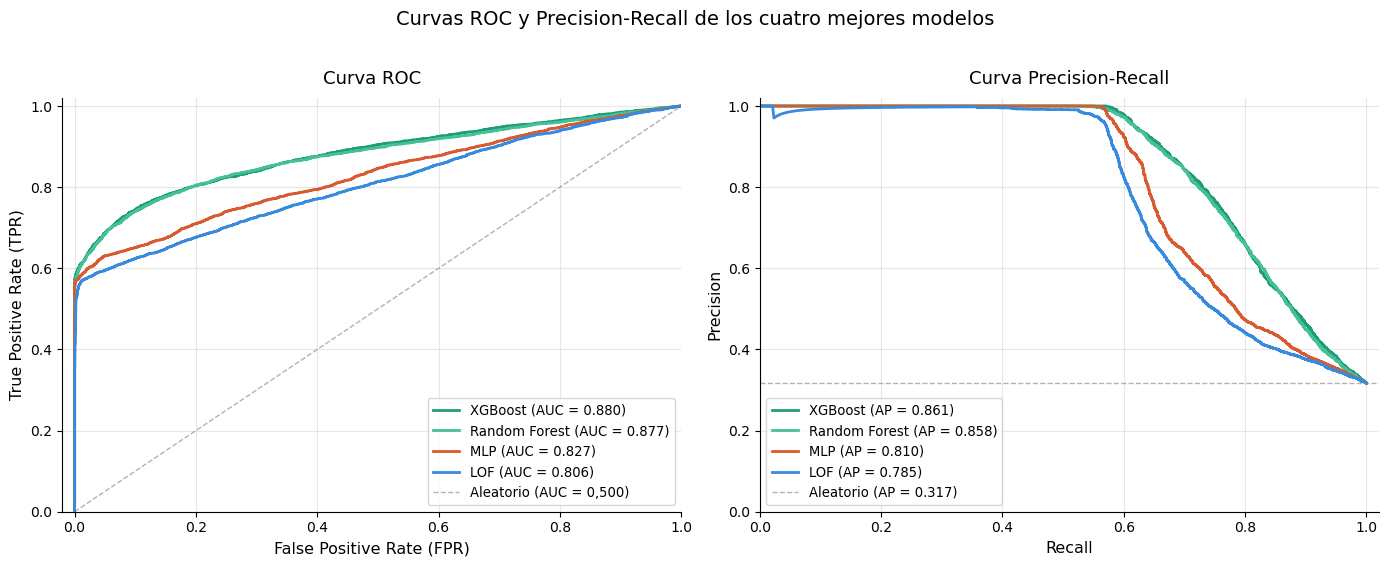

Guardada en: E:\USUARIO\Desktop\Dataset 5\figures\fig_6_7_curvas_roc_pr.png

=== Valores para el texto del apartado ===
XGBoost: AUC-ROC = 0.880, AP = 0.861
Random Forest: AUC-ROC = 0.877, AP = 0.858
MLP: AUC-ROC = 0.827, AP = 0.810
LOF: AUC-ROC = 0.806, AP = 0.785


In [16]:
# =========================================================
# Curvas ROC y Precision-Recall de los 4 mejores modelos
# =========================================================
import joblib
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

# Cargar modelos
rf    = joblib.load(MODELS_DIR / 'rf.joblib')
xgb_m = joblib.load(MODELS_DIR / 'xgb.joblib')
lof   = joblib.load(MODELS_DIR / 'lof.joblib')
mlp   = load_model(MODELS_DIR / 'mlp.keras')

# Scores de cada modelo (probabilidad de la clase "ataque")
scores_rf  = rf.predict_proba(X_test)[:, 1]
scores_xgb = xgb_m.predict_proba(X_test)[:, 1]
scores_mlp = mlp.predict(X_test, verbose=0).ravel()

# LOF: score_samples devuelve "más alto = más normal"
# Invertimos para que "más alto = más anómalo"
scores_lof = -lof.score_samples(X_test)

modelos_curvas = {
    'XGBoost':       (scores_xgb, '#1D9E75'),
    'Random Forest': (scores_rf,  '#45C09A'),
    'MLP':           (scores_mlp, '#D85A30'),
    'LOF':           (scores_lof, '#378ADD'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC
ax = axes[0]
for nombre, (scores, color) in modelos_curvas.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{nombre} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, alpha=0.6, label='Aleatorio (AUC = 0,500)')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11.5)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11.5)
ax.set_title('Curva ROC', fontsize=13, pad=10)
ax.set_xlim(-0.02, 1.0)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower right', fontsize=9.5, frameon=True)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Precision-Recall
ax = axes[1]
for nombre, (scores, color) in modelos_curvas.items():
    prec, rec, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{nombre} (AP = {ap:.3f})')

base = y_test.mean()
ax.axhline(y=base, color='gray', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Aleatorio (AP = {base:.3f})')
ax.set_xlabel('Recall', fontsize=11.5)
ax.set_ylabel('Precision', fontsize=11.5)
ax.set_title('Curva Precision-Recall', fontsize=13, pad=10)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower left', fontsize=9.5, frameon=True)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Curvas ROC y Precision-Recall de los cuatro mejores modelos',
             fontsize=14, y=1.02)
plt.tight_layout()

out_png = FIGURES_DIR / 'fig_6_7_curvas_roc_pr.png'
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
print(f"Guardada en: {out_png}")

# Imprimir valores para copiarlos al texto del TFG
print("\n=== Valores para el texto del apartado ===")
for nombre, (scores, _) in modelos_curvas.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_val = auc(fpr, tpr)
    ap = average_precision_score(y_test, scores)
    print(f"{nombre}: AUC-ROC = {auc_val:.3f}, AP = {ap:.3f}")